# Environment Setup

In [ ]:
# pip install --user tensorflow opencv-python scikit-learn matplotlib

  Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.36.2-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached keras-3.15.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/351.2 MB 3.7 MB/s eta 0:01:36
   ------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.36.2 which is incompatible.


In [6]:
# Core Imports and Setup
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Deep Learning Framework
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Clean output logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


# Dataset Configuration

In [13]:
# Dataset Configuration
from pathlib import Path

# Your exact local dataset path
DATASET_PATH = Path(r"C:\Users\rajen\OneDrive\Desktop\Real_Time_FaceMask Detection\Face Mask Dataset")

TRAIN_DIR = DATASET_PATH / "Train"
VAL_DIR = DATASET_PATH / "Validation"
MODEL_SAVE_PATH = "custom_cnn_mask_model.keras"

IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 10  # Lowered slightly for local execution; Early Stopping will halt if it converges faster

if not TRAIN_DIR.exists():
    raise FileNotFoundError(f"Could not find Train folder at: {TRAIN_DIR}. Check your folder structure.")
else:
    print(f"Local dataset successfully loaded from: {DATASET_PATH}")

Local dataset successfully loaded from: C:\Users\rajen\OneDrive\Desktop\Real_Time_FaceMask Detection\Face Mask Dataset


# Optimized tf.data Pipeline

In [14]:
# Data Loading
print("Building data pipelines from pre-split directories...")

# Load directly from the specific Train and Validation folders
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

CLASS_NAMES = train_ds.class_names
print(f"Detected Classes: {CLASS_NAMES}")

# Performance optimization: Cache and prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(2000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Building data pipelines from pre-split directories...
Found 10000 files belonging to 2 classes.
Found 800 files belonging to 2 classes.
Detected Classes: ['WithMask', 'WithoutMask']


# Custom CNN Architecture

In [15]:
# Building the CNN from Scratch
def build_custom_cnn(input_shape, num_classes):
    model = models.Sequential([
        # Standardize pixel values to [0, 1] internally
        layers.Rescaling(1./255, input_shape=input_shape),
        
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Fully Connected Head
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5), # Regularization to prevent overfitting
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_custom_cnn((IMG_SIZE, IMG_SIZE, 3), len(CLASS_NAMES))
model.summary()

C:\Users\rajen\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,938 (16.36 MB)

 Trainable params: 4,287,938 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

# Model Compilation & Training

In [16]:
# Training Execution
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)
]

print("Training Start...")
print()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_list
)

model.save(MODEL_SAVE_PATH)
print(f"Model successfully saved to {MODEL_SAVE_PATH}")

Training Start...

Epoch 1/10


C:\Users\rajen\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 158ms/step - accuracy: 0.9476 - loss: 0.1387 - val_accuracy: 0.9787 - val_loss: 0.0473 - learning_rate: 0.0010
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 171ms/step - accuracy: 0.9839 - loss: 0.0509 - val_accuracy: 0.9925 - val_loss: 0.0249 - learning_rate: 0.0010
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 149ms/step - accuracy: 0.9887 - loss: 0.0312 - val_accuracy: 0.9962 - val_loss: 0.0167 - learning_rate: 0.0010
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 171ms/step - accuracy: 0.9895 - loss: 0.0266 - val_accuracy: 0.9887 - val_loss: 0.0209 - learning_rate: 0.0010
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 71s 228ms/step - accuracy: 0.9899 - loss: 0.0267 - val_accuracy: 0.9962 - val_loss: 0.0139 - learning_rate: 0.0010
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 155ms/step - accuracy: 0.9926 - loss: 0.0208 - val_accuracy: 0.9912 - val_loss: 0.0159 - learning_rate: 0.0010
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 187ms/step - accuracy: 0.9939 - loss:

# Evaluation Metrics & Visualization

CLASSIFICATION REPORT :

              precision    recall  f1-score   support

    WithMask       1.00      1.00      1.00       400
 WithoutMask       1.00      1.00      1.00       400

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



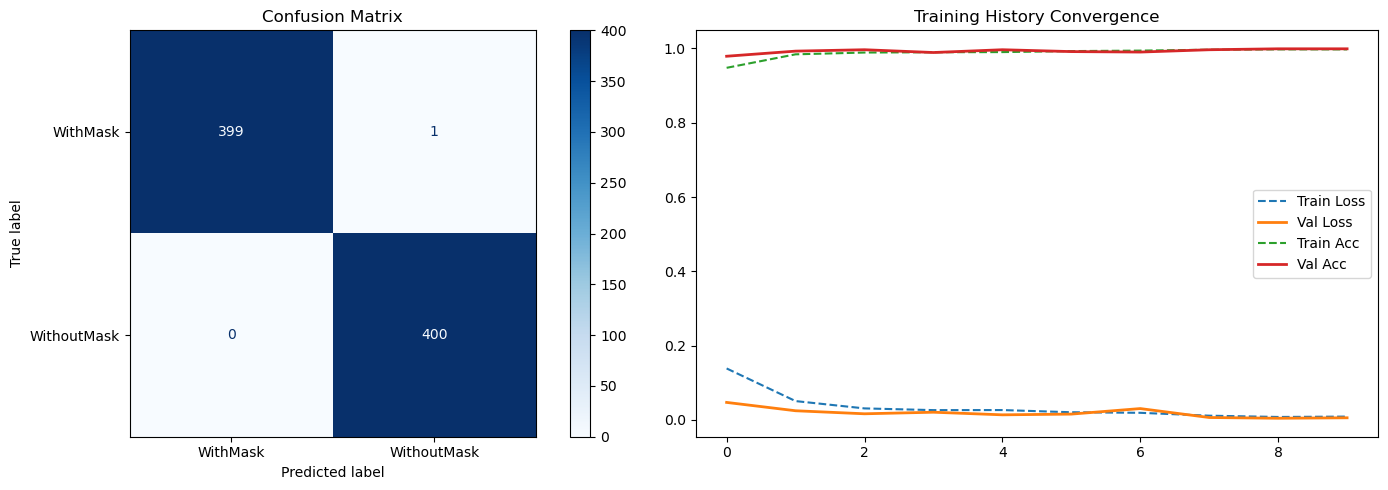

In [17]:
# Scientific Evaluation
y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

unique_labels = np.arange(len(CLASS_NAMES))

print("CLASSIFICATION REPORT :")
print()
print(classification_report(y_true, y_pred, labels=unique_labels, target_names=CLASS_NAMES))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap=plt.cm.Blues, ax=ax[0])
ax[0].set_title("Confusion Matrix")

# Plot 2: Loss & Accuracy Curves
ax[1].plot(history.history['loss'], label='Train Loss', linestyle='--')
ax[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
ax[1].plot(history.history['accuracy'], label='Train Acc', linestyle='--')
ax[1].plot(history.history['val_accuracy'], label='Val Acc', linewidth=2)
ax[1].legend()
ax[1].set_title("Training History Convergence")

plt.tight_layout()
plt.show()